# V-JEPA 2.1 Demo - Vanilla PyTorch (No HuggingFace, No Torch Hub)
This tutorial shows how to load a V-JEPA 2.1 model and extract video features using only the repository's existing functions. No HuggingFace or `torch.hub` is used.
We use the **ViT-Base** checkpoint (80M params, 384 resolution) as an example:- Checkpoint: [vjepa2_1_vitb_dist_vitG_384.pt](https://dl.fbaipublicfiles.com/vjepa2/vjepa2_1_vitb_dist_vitG_384.pt)- Encoder: ViT-Base (768-dim)- Output: return_all_tokens=True returns all patch tokens from the final layer

## 1. Setup: Imports and Utility Functions

In [1]:
import sys
import os
# Add project root to path so 'app' is importable
# Jupyter notebooks run from their directory, so go up one level
project_root = os.path.dirname(os.getcwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import json
import subprocess

import numpy as np
import torch

from decord import VideoReader

# Set device - change to "cuda" if you have a GPU, otherwise keep "cpu"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Repository utilities (no HuggingFace, no torch.hub)
from src.models.attentive_pooler import AttentiveClassifier

# V-JEPA 2.1 specific imports
from app.vjepa_2_1.models import vision_transformer as vit_encoder_21
from src.hub.backbones import _clean_backbone_key, ARCH_NAME_MAP

# Video preprocessing
import src.datasets.utils.video.transforms as video_transforms
import src.datasets.utils.video.volume_transforms as volume_transforms

IMAGENET_DEFAULT_MEAN = (0.485, 0.456, 0.406)
IMAGENET_DEFAULT_STD = (0.229, 0.224, 0.225)
N_FRAMES = 1

print("Imports complete.")

Using device: cpu
Imports complete.


/Users/paul.join.lambert/dev/vjepa2/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
objc[64264]: Class AVFFrameReceiver is implemented in both /opt/homebrew/Cellar/ffmpeg/8.0_2/lib/libavdevice.62.1.100.dylib (0x10e528328) and /Users/paul.join.lambert/dev/vjepa2/.venv/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x11ab603a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[64264]: Class AVFAudioReceiver is implemented in both /opt/homebrew/Cellar/ffmpeg/8.0_2/lib/libavdevice.62.1.100.dylib (0x10e528378) and /Users/paul.join.lambert/dev/vjepa2/.venv/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x11ab603f8). This may cause spurious casting failures and 

## 2. Download the Checkpoint

In [2]:
checkpoint_url = "https://dl.fbaipublicfiles.com/vjepa2/vjepa2_1_vitb_dist_vitG_384.pt"
checkpoint_path = "vjepa2_1_vitb_dist_vitG_384.pt"

if not os.path.exists(checkpoint_path):
    print(f"Downloading checkpoint from {checkpoint_url}...")
    subprocess.run(["wget", checkpoint_url, "-O", checkpoint_path], check=True)
else:
    print(f"Checkpoint already exists at {checkpoint_path}")

# Also download a sample video
sample_video_path = "sample_video.mp4"
if not os.path.exists(sample_video_path):
    video_url = "https://huggingface.co/datasets/nateraw/kinetics-mini/resolve/main/val/bowling/-WH-lxmGJVY_000005_000015.mp4"
    subprocess.run(["wget", video_url, "-O", sample_video_path], check=True)
    print("Downloaded sample video")
else:
    print("Sample video already exists")

# Download SSV2 classes for classifier interpretation
ssv2_classes_path = "ssv2_classes.json"
if not os.path.exists(ssv2_classes_path):
    subprocess.run([
        "wget",
        "https://huggingface.co/datasets/huggingface/label-files/resolve/d79675f2d50a7b1ecf98923d42c30526a51818e2/"
        "something-something-v2-id2label.json",
        "-O", ssv2_classes_path,
    ], check=True)
    print("Downloaded SSV2 classes")

print("Setup complete.")

Checkpoint already exists at vjepa2_1_vitb_dist_vitG_384.pt
Sample video already exists
Setup complete.


## 3. Build the V-JEPA 2.1 Encoder (Vanilla PyTorch Only)

There are **two ways** to build the model. Both use only repo internals.
### Approach A: Using `app.vjepa_2_1.models.vision_transformer`
This directly instantiates the V-JEPA 2.1 Vision Transformer with the correct parameters for the ViT-Base checkpoint.

In [3]:
def build_vjepa2_1_encoder_vanilla(
    img_size=384,
    patch_size=16,
    num_frames=64,
    tubelet_size=2,
    model_arch="vit_base",
):
    """
    Build a V-JEPA 2.1 encoder using only repository code (no HuggingFace, no torch.hub).
    
    Args:
        img_size: Spatial resolution (default 384 for all public checkpoints)
        patch_size: Patch size (16 for all public checkpoints)
        num_frames: Number of input frames (64 for all public checkpoints)
        tubelet_size: Temporal tubelet size (2 for all public checkpoints)
        model_arch: Architecture name, e.g. "vit_base", "vit_large", "vit_giant_xformers"
    
    Returns:
        encoder: VisionTransformer instance
    """
    encoder = vit_encoder_21.__dict__[model_arch](
        img_size=(img_size, img_size),
        patch_size=patch_size,
        num_frames=num_frames,
        tubelet_size=tubelet_size,
        use_sdpa=True,
        use_SiLU=False,
        wide_SiLU=True,
        uniform_power=False,
        use_rope=True,
        img_temporal_dim_size=N_FRAMES,
        interpolate_rope=True,
        return_all_tokens=False,
        n_output_distillation=1,  # ViT-Base uses 1
    )
    return encoder


def load_checkpoint_vanilla(encoder, checkpoint_path, checkpoint_key="ema_encoder"):
    """
    Load a V-JEPA 2.1 checkpoint into an encoder using only repo internals.
    
    Args:
        encoder: VisionTransformer instance
        checkpoint_path: Path to the .pt checkpoint file
        checkpoint_key: Key in the checkpoint for encoder weights
                       - V-JEPA 2.x uses "encoder" or "target_encoder"
                       - V-JEPA 2.1 uses "ema_encoder"
    """
    # Load the raw state dict from disk
    checkpoint = torch.load(checkpoint_path, weights_only=True, map_location="cpu")
    
    # Extract the encoder weights
    pretrained_dict = checkpoint[checkpoint_key]
    
    # Clean the keys: remove "module." and "backbone." prefixes
    pretrained_dict = _clean_backbone_key(pretrained_dict)
    
    # Load into the encoder
    msg = encoder.load_state_dict(pretrained_dict, strict=True)
    print(f"Loaded checkpoint from {checkpoint_path}")
    print(f"  Missing keys: {msg.missing_keys}")
    print(f"  Unexpected keys: {msg.unexpected_keys}")
    
    return encoder


# Build and load the ViT-Base encoder
img_size = 384
num_frames = 64
patch_size = 16
tubelet_size = 2

print("Building V-JEPA 2.1 ViT-Base encoder...")
encoder = build_vjepa2_1_encoder_vanilla(
    img_size=img_size,
    patch_size=patch_size,
    num_frames=num_frames,
    tubelet_size=tubelet_size,
    model_arch="vit_base",
)

print("Loading checkpoint...")
encoder = load_checkpoint_vanilla(
    encoder,
    checkpoint_path,
    checkpoint_key="ema_encoder",
)

encoder.to(device).eval()
print(f"Encoder embed_dim: {encoder.embed_dim}")
print("Encoder ready.")

Building V-JEPA 2.1 ViT-Base encoder...
Loading checkpoint...
Loaded checkpoint from vjepa2_1_vitb_dist_vitG_384.pt
  Missing keys: []
  Unexpected keys: []
Encoder embed_dim: 768
Encoder ready.


### Approach B: Using the Backbone Factory (`src.hub.backbones`)
Alternatively, use the `_make_vjepa2_1_model` factory function from the repo. Pass `pretrained=False` and load manually for full control.

In [4]:
# from src.hub.backbones import _make_vjepa2_1_model
# encoder_b, predictor_b = _make_vjepa2_1_model(
#     model_name="vjepa2_1_vit_base_384",
#     checkpoint_key="ema_encoder",
#     img_size=384,
#     predictor_depth=12,
#     predictor_num_mask_tokens=8,
#     n_output_distillation=1,
#     return_all_tokens=True,
#     teacher_embed_dim=1664,
#     pretrained=False,  # Skip automatic download
# )
# # Then manually load the checkpoint as in Approach A above

print("Approach B shown as commented code.")
print("Approach A (above) is preferred for fully manual control.")

Approach B shown as commented code.
Approach A (above) is preferred for fully manual control.


## 4. Video Preprocessing

In [5]:
def build_video_transform(img_size):
    """Build the video preprocessing transform used by V-JEPA."""
    short_side_size = int(256.0 / 224 * img_size)
    eval_transform = video_transforms.Compose([
        video_transforms.Resize(short_side_size, interpolation="bilinear"),
        video_transforms.CenterCrop(size=(img_size, img_size)),
        volume_transforms.ClipToTensor(),
        video_transforms.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD),
    ])
    return eval_transform


def read_video(path, num_frames=64):
    """Read a video file and return a tensor of shape (T, C, H, W)."""
    vr = VideoReader(path)
    total_frames = len(vr)
    # Sample frames uniformly
    frame_idx = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    video = vr.get_batch(frame_idx).asnumpy()
    # Convert from (T, H, W, C) to (T, C, H, W)
    video = torch.from_numpy(video).permute(0, 3, 1, 2).float()
    return video


# Verify video reading works
video = read_video(sample_video_path, num_frames=8)
print(f"Video shape: {video.shape}  (T, C, H, W)")

# Build transform
video_transform = build_video_transform(img_size)
print(f"Transform built for img_size={img_size}")

Video shape: torch.Size([8, 3, 270, 480])  (T, C, H, W)
Transform built for img_size=384


## 5. Feature Extraction

In [6]:
def extract_features(encoder, video_tensor):    
    """
    Extract patch-wise features from a video using the V-JEPA 2.1 encoder.    
    Args:        encoder: Loaded V-JEPA 2.1 VisionTransformer        video_tensor: Raw video tensor of shape (T, C, H, W)    
    Returns:        features: Patch tokens of shape (B, N, D) where N = num_patches    """
    with torch.inference_mode():        # Permute (T, C, H, W) -> (C, T, H, W), then add batch dim -> (B, C, T, H, W)        
        x = video_tensor.permute(1, 0, 2, 3).unsqueeze(0).to(device)        
        # Forward pass through encoder
        features = encoder(x)        
        return features
        
        # Run inference with a short clipvideo_short = read_video(sample_video_path, num_frames=8)print(f"Raw video shape: {video_short.shape} (T, C, H, W)")features = extract_features(encoder, video_short)print(f"Feature shape: {features.shape}")
print(f"Expected: (batch=1, num_patches=576, embed_dim=768)")
# For img_size=384, patch_size=16: num_patches = (384/16) * (384/16) = 24 * 24 = 576expected_patches = (img_size // patch_size) ** 2print(f"Actual patches: {features.shape[1]}, Expected: {expected_patches}")

Expected: (batch=1, num_patches=576, embed_dim=768)


## 6. (Optional) Classification with Attentive Classifier

You can attach a pretrained attentive probe classifier to the extracted features.
Download the SSV2 classifier checkpoint:```bash
wget https://dl.fbaipublicfiles.com/vjepa2/evals/ssv2-vitb-384-64x2x3.pt
```

In [7]:
import torch.nn.functional as F

def load_classifier(classifier_path):
    """Load a pretrained attentive classifier."""
    checkpoint = torch.load(classifier_path, weights_only=True, map_location="cpu")
    classifier = AttentiveClassifier(
        embed_dim=encoder.embed_dim,
        num_heads=12,  # ViT-Base uses 12 heads
        depth=4,
        num_classes=174,
    ).to(device).eval()    
    pretrained_dict = checkpoint["classifiers"][0]
    pretrained_dict = {k.replace("module.", ""): v for k, v in pretrained_dict.items()}
    msg = classifier.load_state_dict(pretrained_dict, strict=False)
    print(f"Classifier loaded with msg: {msg}")
    return classifier


def classify_video(classifier, features):
    """Run classification on extracted features."""
    with torch.inference_mode():
        logits = classifier(features)
    
    with open("ssv2_classes.json", "r") as f:
        classes = json.load(f)
    
    top5_probs, top5_indices = F.softmax(logits, dim=-1).topk(5)
    print("Top 5 predictions:")
    for prob, idx in zip(top5_probs[0], top5_indices[0]):
        name = classes[str(idx.item())]
        print(f"  {name}: {prob.item()*100:.2f}%")


# Uncomment to run (requires classifier checkpoint)
# classifier_path = "ssv2-vitb-384-64x2x3.pt"
# if not os.path.exists(classifier_path):
#     subprocess.run(["wget", "https://dl.fbaipublicfiles.com/vjepa2/evals/ssv2-vitb-384-64x2x3.pt", "-O", classifier_path])
# classifier = load_classifier(classifier_path)
# classify_video(classifier, features)

## 7. Loading Any V-JEPA 2.1 Checkpoint

| Model | Params | Resolution | Architecture | Checkpoint |
|-------|--------|------------|-------------|------------|
| ViT-Base | 80M | 384 | vit_base | vjepa2_1_vitb_dist_vitG_384.pt |
| ViT-Large | 304M | 384 | vit_large | vjepa2_1_vitl_dist_vitG_384.pt |
| ViT-Giant | 1.0B | 384 | vit_giant_xformers | vjepa2_1_vitg_384.pt |
| ViT-Gigantic | 1.6B | 384 | vit_gigantic_xformers | vjepa2_1_vitG_384.pt |

In [8]:
def load_vjepa2_1_model(model_name: str, checkpoint_path: str, img_size: int = 384):
    """
    One-shot function to load any V-JEPA 2.1 model.
    
    Args:
        model_name: One of "vit_base", "vit_large", "vit_giant_xformers", "vit_gigantic_xformers"
        checkpoint_path: Path to the downloaded .pt checkpoint
        img_size: Spatial resolution (always 384 for public checkpoints)
    
    Returns:
        encoder: Loaded V-JEPA 2.1 VisionTransformer
    """
    config = {
        "vit_base": {"n_output_distillation": 1},
        "vit_large": {"n_output_distillation": 1},
        "vit_giant_xformers": {"n_output_distillation": 4},
        "vit_gigantic_xformers": {"n_output_distillation": 4},
    }
    
    encoder = vit_encoder_21.__dict__[model_name](
        img_size=(img_size, img_size),
        patch_size=16,
        num_frames=64,
        tubelet_size=2,
        use_sdpa=True,
        use_SiLU=False,
        wide_SiLU=True,
        uniform_power=False,
        use_rope=True,
        img_temporal_dim_size=1,
        interpolate_rope=True,
        return_all_tokens=True,
        n_output_distillation=config[model_name]["n_output_distillation"],
    )
    
    encoder = load_checkpoint_vanilla(encoder, checkpoint_path, checkpoint_key="ema_encoder")
    encoder.to(device).eval()    
    return encoder


# Example: Load ViT-Large
# encoder_large = load_vjepa2_1_model(
#     model_name="vit_large",
#     checkpoint_path="vjepa2_1_vitl_dist_vitG_384.pt",
# )

print("load_vjepa2_1_model function ready for any V-JEPA 2.1 checkpoint.")

load_vjepa2_1_model function ready for any V-JEPA 2.1 checkpoint.


## 8. V-JEPA 2 vs V-JEPA 2.1
The `src/models/vision_transformer.py` module contains the original V-JEPA 2 (non-2.1) Vision Transformer **without RoPE**. The V-JEPA 2.1 encoder in `app.vjepa_2_1/models/vision_transformer.py` adds **RoPE**, distillation tokens, and other changes. You **must** use the 2.1-specific module for 2.1 checkpoints.

In [9]:
print("V-JEPA 2 vs V-JEPA 2.1 key differences:")
print("  V-JEPA 2:   src/models/vision_transformer.py (no RoPE, checkpoint key='encoder')")
print("  V-JEPA 2.1: app.vjepa_2_1/models/vision_transformer.py (RoPE, checkpoint key='ema_encoder')")
print()
print("This demo uses V-JEPA 2.1 exclusively - no HuggingFace, no torch.hub.")

V-JEPA 2 vs V-JEPA 2.1 key differences:
  V-JEPA 2:   src/models/vision_transformer.py (no RoPE, checkpoint key='encoder')
  V-JEPA 2.1: app.vjepa_2_1/models/vision_transformer.py (RoPE, checkpoint key='ema_encoder')

This demo uses V-JEPA 2.1 exclusively - no HuggingFace, no torch.hub.


## 9. Visualizing Patch EmbeddingsThis section demonstrates how to visualize the patch embeddings extracted by the V-JEPA 2.1 encoder.We'll reshape the 1D token sequence back into a 2D spatial grid and display it as a heatmap.For an input of size 384x384 with patch size 16, we get a 24x24 grid of embeddings (576 patches total).

Features shape: torch.Size([1, 480, 768])
Grid size: 24x24
Detected grid: 16x30 = 480 tokens
Video sample shape before transform: torch.Size([1, 3, 270, 480])
Transformed shape: torch.Size([3, 1, 384, 384])
After squeeze: torch.Size([3, 384, 384])
Final display shape: (384, 384, 3)


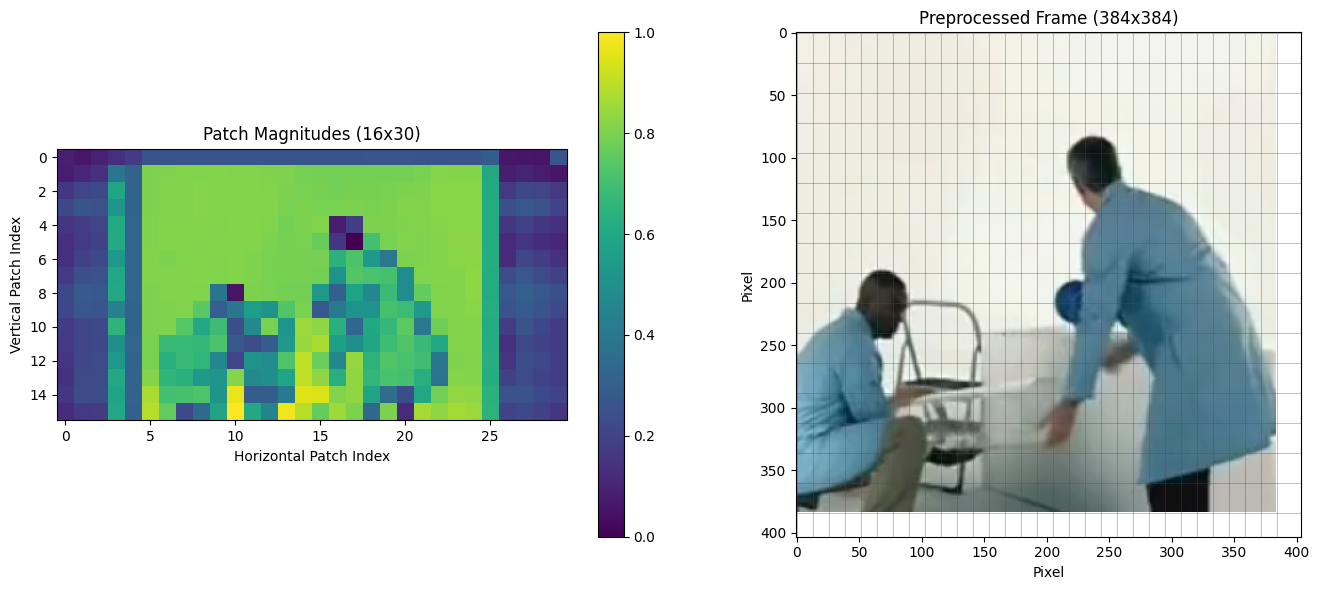

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_patch_embeddings(features, img_size=384, patch_size=16):
    """
    Visualize patch embeddings as a spatial heatmap.
    Automatically detects the grid size from token count.
    """
    tokens = features[0]  # (N, D)
    patch_scores = torch.norm(tokens, dim=-1).cpu().numpy()  # (N,)
    
    n_tokens = len(patch_scores)
    
    # Try to find the grid dimensions
    import math
    sqrt_tokens = int(math.sqrt(n_tokens))
    
    # Find the best factor pair
    best_factors = None
    for h in range(1, sqrt_tokens + 1):
        if n_tokens % h == 0:
            w = n_tokens // h
            if 15 <= h <= 30 and 15 <= w <= 30:  # Reasonable patch counts
                best_factors = (h, w)
                break
    
    if best_factors:
        grid_h, grid_w = best_factors
        print(f"Detected grid: {grid_h}x{grid_w} = {n_tokens} tokens")
        spatial_map = patch_scores.reshape(grid_h, grid_w)
    else:
        raise ValueError(f"Cannot factor {n_tokens} into a reasonable grid (tried 15-30 patches per side)")
    
    # Normalize to [0, 1]
    spatial_map = (spatial_map - spatial_map.min()) / (spatial_map.max() - spatial_map.min() + 1e-8)
    
    # Get the preprocessed frame for display
    video_sample = read_video(sample_video_path, num_frames=1)  # (T=1, C, H, W)
    print(f"Video sample shape before transform: {video_sample.shape}")
    
    frame_transformed = video_transform(video_sample)  # Apply transforms
    print(f"Transformed shape: {frame_transformed.shape}")
    
    # Ensure on CPU and squeeze all singleton dimensions
    frame_transformed = frame_transformed.cpu()
    frame_transformed = frame_transformed.squeeze()  # Remove ALL singletons
    print(f"After squeeze: {frame_transformed.shape}")  # Should be (C, H, W)
    
    # Permute to (H, W, C) and de-normalize
    frame_display = frame_transformed.permute(1, 2, 0)  # (H, W, C)
    frame_display = frame_display * torch.tensor(IMAGENET_DEFAULT_STD).view(1, 1, -1) + \
                    torch.tensor(IMAGENET_DEFAULT_MEAN).view(1, 1, -1)
    frame_display = torch.clamp(frame_display, 0, 1).numpy()
    
    print(f"Final display shape: {frame_display.shape}")
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Heatmap
    im1 = axes[0].imshow(spatial_map, cmap='viridis', interpolation='nearest')
    axes[0].set_title(f'Patch Magnitudes ({grid_h}x{grid_w})')
    axes[0].set_xlabel('Horizontal Patch Index')
    axes[0].set_ylabel('Vertical Patch Index')
    plt.colorbar(im1, ax=axes[0])
    
    # Frame with grid
    axes[1].imshow(frame_display)
    axes[1].set_title(f'Preprocessed Frame ({frame_display.shape[0]}x{frame_display.shape[1]})')
    for i in range(grid_w + 1):
        x = i * (frame_display.shape[1] / grid_w)
        axes[1].axvline(x=x, color='red', linewidth=0.5, alpha=0.5)
    for i in range(grid_h + 1):
        y = i * (frame_display.shape[0] / grid_h)
        axes[1].axhline(y=y, color='red', linewidth=0.5, alpha=0.5)
    axes[1].set_xlabel('Pixel')
    axes[1].set_ylabel('Pixel')
    
    plt.tight_layout()
    plt.show()


# Run inference and visualize
video_viz = read_video(sample_video_path, num_frames=1)
features_viz = extract_features(encoder, video_viz)

print(f'Features shape: {features_viz.shape}')
print(f'Grid size: {img_size // patch_size}x{img_size // patch_size}')

# Visualize patch embeddings
visualize_patch_embeddings(features_viz, img_size=img_size, patch_size=patch_size)